In [ ]:
# --- INSTALLS ---
!pip install torch torchvision torchaudio
!pip install pandas numpy scipy scikit-learn tqdm sentence-transformers matplotlib

# --- IMPORTS & DRIVE SETUP ---
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from scipy.sparse import coo_matrix, hstack, vstack
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import gzip
import json
import os
import math
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# Set up drive path
base_path = "/content/drive/MyDrive/slightgcn"
os.makedirs(base_path, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
# --- DATA LOADING ---
!wget -nc https://mcauleylab.ucsd.edu/public_datasets/data/amazon_v2/categoryFilesSmall/Movies_and_TV_5.json.gz

data = []
with gzip.open("Movies_and_TV_5.json.gz") as f:
    for i, line in enumerate(f):
        data.append(json.loads(line))
        if i == 300000: break

reviews = pd.DataFrame(data)[["reviewerID", "asin", "overall", "reviewText"]]
reviews.rename(columns={"reviewerID":"userId", "asin":"itemId", "overall":"rating"}, inplace=True)
reviews = reviews[reviews["rating"] >= 4]

user_map = {u:i for i,u in enumerate(reviews["userId"].unique())}
item_map = {i:j for j,i in enumerate(reviews["itemId"].unique())}
reviews["userId"] = reviews["userId"].map(user_map)
reviews["itemId"] = reviews["itemId"].map(item_map)

n_users = len(user_map)
n_items = len(item_map)
print(f"Users: {n_users}, Items: {n_items}")



--2026-05-08 10:18:06--  https://mcauleylab.ucsd.edu/public_datasets/data/amazon_v2/categoryFilesSmall/Movies_and_TV_5.json.gz
Resolving mcauleylab.ucsd.edu (mcauleylab.ucsd.edu)... 137.110.161.5
Connecting to mcauleylab.ucsd.edu (mcauleylab.ucsd.edu)|137.110.161.5|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791152395 (755M) [application/gzip]
Saving to: ‘Movies_and_TV_5.json.gz’

Movies_and_TV_5.jso 100%[===================>] 754.50M  17.3MB/s    in 43s     

2026-05-08 10:18:50 (17.7 MB/s) - ‘Movies_and_TV_5.json.gz’ saved [791152395/791152395]

Users: 113819, Items: 3886


In [ ]:
# --- TRAIN/TEST SPLIT (LOCKED SEED) ---
train_list, test_list = [], []
for user in reviews["userId"].unique():
    user_data = reviews[reviews["userId"] == user]
    if len(user_data) < 2: continue

    test_sample = user_data.sample(1, random_state=42)
    train_sample = user_data.drop(test_sample.index)

    train_list.append(train_sample)
    test_list.append(test_sample)

train = pd.concat(train_list)
test = pd.concat(test_list)
print(f"Train size: {len(train)}, Test size: {len(test)}")

# --- ORIGINAL GLOBAL EVALUATION VARIABLES ---
# O(1) lookup dictionary
test_dict = {user: test[test["userId"]==user]["itemId"].values[0] for user in test["userId"].unique()}

# Original cold item definition (Filters out 0-degree items inherently)
item_counts = train["itemId"].value_counts()
cold_items = set(item_counts[item_counts < 5].index.values)
print(f"Number of Cold Items defined: {len(cold_items)}")

# --- GRAPH SETUP ---
rows, cols = train["userId"].values, train["itemId"].values
interaction_matrix = coo_matrix((np.ones(len(rows)),(rows,cols)), shape=(n_users,n_items))

upper = hstack([coo_matrix((n_users,n_users)), interaction_matrix])
lower = hstack([interaction_matrix.T, coo_matrix((n_items,n_items))])
adj = vstack([upper, lower]).tocoo()

rowsum = np.array(adj.sum(1)).flatten()
d_inv_sqrt = np.power(rowsum, -0.5)
d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.
D_inv_sqrt = coo_matrix((d_inv_sqrt,(range(len(d_inv_sqrt)),range(len(d_inv_sqrt)))), shape=(adj.shape[0],adj.shape[0]))

adj_norm = D_inv_sqrt.dot(adj).dot(D_inv_sqrt).tocoo()
indices = torch.LongTensor([adj_norm.row, adj_norm.col])
values = torch.FloatTensor(adj_norm.data)
adj_norm_torch = torch.sparse.FloatTensor(indices,values,torch.Size(adj_norm.shape)).to(device)

# --- TEXT EMBEDDINGS ---
item_reviews = reviews.groupby("itemId")["reviewText"].apply(list)
texts = []
for r in item_reviews:
    valid = [str(x) for x in r if isinstance(x, str)]
    text = " ".join(valid)
    texts.append(text[:512])  # Maximize text context up to 512 characters

emb_path = f"{base_path}/item_text_emb.npy"

if os.path.exists(emb_path):
    print("Loading pre-computed text embeddings...")
    text_matrix = np.load(emb_path)
else:
    print("Computing text embeddings with Sentence-BERT...")
    model_text = SentenceTransformer("all-MiniLM-L6-v2")
    item_text_emb = model_text.encode(texts, show_progress_bar=True)

    text_matrix = np.zeros((n_items, item_text_emb.shape[1]))
    for item_id, emb in zip(item_reviews.index, item_text_emb):
        text_matrix[item_id] = emb
    np.save(emb_path, text_matrix)
    print("Text embeddings saved to disk!")



Train size: 137666, Test size: 47940
Number of Cold Items defined: 994


/tmp/ipykernel_629/952044738.py:35: RuntimeWarning: divide by zero encountered in power
  d_inv_sqrt = np.power(rowsum, -0.5)
/tmp/ipykernel_629/952044738.py:40: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  indices = torch.LongTensor([adj_norm.row, adj_norm.col])
/tmp/ipykernel_629/952044738.py:42: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:654.)
  adj_norm_torch = torch.sparse.FloatTensor(indices,values,torch.Size(adj_norm.shape)).to(device)


Computing text embeddings with Sentence-BERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/122 [00:00<?, ?it/s]

Text embeddings saved to disk!


In [ ]:
# --- HELPER FUNCTIONS ---
def sample_batch(train_df, batch_size):
    users = train_df["userId"].unique()
    batch_users = np.random.choice(users, batch_size)
    pos_items, neg_items = [], []
    for u in batch_users:
        user_items = train_df[train_df["userId"]==u]["itemId"].values
        user_items_set = set(user_items)
        pos = np.random.choice(user_items)
        neg = np.random.randint(0, n_items)
        while neg in user_items_set:
            neg = np.random.randint(0, n_items)
        pos_items.append(pos)
        neg_items.append(neg)
    return (torch.LongTensor(batch_users).to(device), torch.LongTensor(pos_items).to(device), torch.LongTensor(neg_items).to(device))

def train_model(model, epochs=30):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    batch_size = 1024
    loss_history = []

    for epoch in range(epochs):
        model.train()
        n_batches = len(train) // batch_size
        total_loss = 0
        for _ in range(n_batches):
            users, pos, neg = sample_batch(train, batch_size)
            users_emb, items_emb = model(adj_norm_torch)
            u = users_emb[users]
            pos_i, neg_i = items_emb[pos], items_emb[neg]
            pos_scores = (u * pos_i).sum(dim=1)
            neg_scores = (u * neg_i).sum(dim=1)
            bpr_loss = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()
            u0 = model.user_emb.weight[users]
            p0 = model.item_emb.weight[pos]
            n0 = model.item_emb.weight[neg]
            reg_loss = (u0.norm(2).pow(2) + p0.norm(2).pow(2) + n0.norm(2).pow(2)) / (2 * batch_size)
            loss = bpr_loss + 1e-4 * reg_loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        epoch_loss = total_loss / n_batches
        loss_history.append(epoch_loss)
        print(f"Epoch {epoch} | Loss: {epoch_loss:.4f}")

    return loss_history

def evaluate_and_save(model, model_name):
    print(f"Evaluating {model_name}...")
    model.eval()

    metrics = {f"{model_name}_{k}": [] for k in ["Recall@10", "Recall@20", "NDCG@10", "NDCG@20", "ColdRecall@10", "ColdRecall@20"]}

    with torch.no_grad():
        users_emb, items_emb = model(adj_norm_torch)

        for user in test["userId"].unique():
            test_item = test_dict[user]
            user_vector = users_emb[user]
            scores = torch.matmul(items_emb, user_vector)

            seen = train[train["userId"]==user]["itemId"].values
            scores[seen] = -1e9

            _, topk = torch.topk(scores, 20)
            topk_numpy = topk.cpu().numpy()

            for K in [10, 20]:
                hit = int(test_item in topk_numpy[:K])
                metrics[f"{model_name}_Recall@{K}"].append(hit)
                if hit:
                    rank = np.where(topk_numpy[:K] == test_item)[0][0]
                    metrics[f"{model_name}_NDCG@{K}"].append(1.0 / math.log2(rank + 2))
                else:
                    metrics[f"{model_name}_NDCG@{K}"].append(0.0)

            if test_item in cold_items:
                for K in [10, 20]:
                    hit = int(test_item in topk_numpy[:K])
                    metrics[f"{model_name}_ColdRecall@{K}"].append(hit)

    final_metrics = {k: (np.mean(v) if len(v) > 0 else 0.0) for k, v in metrics.items()}

    results_file = f"{base_path}/results.json"
    if os.path.exists(results_file):
        with open(results_file, "r") as f: all_results = json.load(f)
    else: all_results = {}

    all_results.update(final_metrics)
    with open(results_file, "w") as f: json.dump(all_results, f, indent=4)

    print("Metrics Saved:")
    for k, v in final_metrics.items():
        print(f"  {k}: {v:.4f}")

# Dictionary to hold loss curves for plotting
all_loss_histories = {}

loss_file = f"{base_path}/loss_histories.json"
def save_loss(name, history):
    all_loss_histories[name] = history
    with open(loss_file, "w") as f: json.dump(all_loss_histories, f)

In [ ]:
class BPRMF(nn.Module):
    def __init__(self, n_users, n_items, emb_dim):
        super().__init__()
        self.n_users, self.n_items = n_users, n_items
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)
    def forward(self, adj=None):
        return self.user_emb.weight, self.item_emb.weight

class NGCF(nn.Module):
    def __init__(self, n_users, n_items, emb_dim, n_layers):
        super().__init__()
        self.n_users, self.n_items, self.n_layers = n_users, n_items, n_layers
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)
        self.W1 = nn.ParameterList([nn.Parameter(torch.Tensor(emb_dim, emb_dim)) for _ in range(n_layers)])
        self.W2 = nn.ParameterList([nn.Parameter(torch.Tensor(emb_dim, emb_dim)) for _ in range(n_layers)])
        for w1, w2 in zip(self.W1, self.W2):
            nn.init.xavier_uniform_(w1)
            nn.init.xavier_uniform_(w2)
        self.leaky_relu = nn.LeakyReLU(0.2)
    def forward(self, adj):
        E = torch.cat([self.user_emb.weight, self.item_emb.weight], dim=0)
        all_embeddings = [E]
        for k in range(self.n_layers):
            side_E = torch.sparse.mm(adj, E)
            sum_E = torch.matmul(E + side_E, self.W1[k])
            bi_E = torch.matmul(E * side_E, self.W2[k])
            E = nn.functional.normalize(self.leaky_relu(sum_E + bi_E), p=2, dim=1)
            all_embeddings.append(E)
        E_final = torch.cat(all_embeddings, dim=1)
        return E_final[:self.n_users], E_final[self.n_users:]

class LightGCN(nn.Module):
    def __init__(self,n_users,n_items,emb_dim,n_layers):
        super().__init__()
        self.n_users, self.n_items, self.n_layers = n_users, n_items, n_layers
        self.user_emb = nn.Embedding(n_users,emb_dim)
        self.item_emb = nn.Embedding(n_items,emb_dim)
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)
    def forward(self,adj):
        E0 = torch.cat([self.user_emb.weight,self.item_emb.weight],dim=0)
        all_embeddings, E = [E0], E0
        for _ in range(self.n_layers):
            E = torch.sparse.mm(adj,E)
            all_embeddings.append(E)
        E_final = torch.mean(torch.stack(all_embeddings,dim=0),dim=0)
        return E_final[:self.n_users], E_final[self.n_users:]

class SLightGCN(nn.Module):
    def __init__(self, n_users, n_items, emb_dim, n_layers, text_emb, alpha=0.1):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.n_layers = n_layers

        # Fixed Alpha: Treated as a static structural prior
        self.alpha = alpha

        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        self.text_proj = nn.Linear(text_emb.shape[1], emb_dim, bias=False)
        self.register_buffer("text_emb", torch.tensor(text_emb, dtype=torch.float32))

        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)
        nn.init.xavier_uniform_(self.text_proj.weight)

    def forward(self, adj):
        item_semantic = self.text_proj(self.text_emb)

        item_initial = self.item_emb.weight + (self.alpha * item_semantic)

        E0 = torch.cat([self.user_emb.weight, item_initial], dim=0)
        all_embeddings, E = [E0], E0

        for _ in range(self.n_layers):
            E = torch.sparse.mm(adj, E)
            all_embeddings.append(E)

        E_final = torch.mean(torch.stack(all_embeddings, dim=0), dim=0)
        return E_final[:self.n_users], E_final[self.n_users:]


In [ ]:
# 1. BPR-MF
print("--- Checking BPR-MF ---")
model_mf = BPRMF(n_users, n_items, 64).to(device)
mf_path = f"{base_path}/bprmf_baseline.pt"
if os.path.exists(mf_path):
    print("Loading BPR-MF from disk...")
    model_mf.load_state_dict(torch.load(mf_path, weights_only=True))
else:
    print("Training BPR-MF...")
    all_loss_histories["BPR-MF"] = train_model(model_mf)
    save_loss("BPR-MF", all_loss_histories["BPR-MF"])
    torch.save(model_mf.state_dict(), mf_path)
    evaluate_and_save(model_mf, "BPR-MF")

--- Checking BPR-MF ---
Training BPR-MF...
Epoch 0 | Loss: 0.6881
Epoch 1 | Loss: 0.6356
Epoch 2 | Loss: 0.5176
Epoch 3 | Loss: 0.4000
Epoch 4 | Loss: 0.3120
Epoch 5 | Loss: 0.2527
Epoch 6 | Loss: 0.2098
Epoch 7 | Loss: 0.1786
Epoch 8 | Loss: 0.1531
Epoch 9 | Loss: 0.1345
Epoch 10 | Loss: 0.1174
Epoch 11 | Loss: 0.1041
Epoch 12 | Loss: 0.0941
Epoch 13 | Loss: 0.0848
Epoch 14 | Loss: 0.0774
Epoch 15 | Loss: 0.0702
Epoch 16 | Loss: 0.0641
Epoch 17 | Loss: 0.0591
Epoch 18 | Loss: 0.0541
Epoch 19 | Loss: 0.0506
Epoch 20 | Loss: 0.0473
Epoch 21 | Loss: 0.0437
Epoch 22 | Loss: 0.0404
Epoch 23 | Loss: 0.0387
Epoch 24 | Loss: 0.0363
Epoch 25 | Loss: 0.0338
Epoch 26 | Loss: 0.0326
Epoch 27 | Loss: 0.0309
Epoch 28 | Loss: 0.0294
Epoch 29 | Loss: 0.0277
Evaluating BPR-MF...
Metrics Saved:
  BPR-MF_Recall@10: 0.0336
  BPR-MF_Recall@20: 0.0518
  BPR-MF_NDCG@10: 0.0192
  BPR-MF_NDCG@20: 0.0237
  BPR-MF_ColdRecall@10: 0.0127
  BPR-MF_ColdRecall@20: 0.0127


In [ ]:
# 2. NGCF
print("--- Checking NGCF ---")
model_ngcf = NGCF(n_users, n_items, 64, 3).to(device)
ngcf_path = f"{base_path}/ngcf_baseline.pt"
if os.path.exists(ngcf_path):
    print("Loading NGCF from disk...")
    model_ngcf.load_state_dict(torch.load(ngcf_path, weights_only=True))
else:
    print("Training NGCF...")
    all_loss_histories["NGCF"] = train_model(model_ngcf)
    save_loss("NGCF", all_loss_histories["NGCF"])
    torch.save(model_ngcf.state_dict(), ngcf_path)
    evaluate_and_save(model_ngcf, "NGCF")

--- Checking NGCF ---
Training NGCF...
Epoch 0 | Loss: 0.1925
Epoch 1 | Loss: 0.1472
Epoch 2 | Loss: 0.1312
Epoch 3 | Loss: 0.1215
Epoch 4 | Loss: 0.1141
Epoch 5 | Loss: 0.1095
Epoch 6 | Loss: 0.1049
Epoch 7 | Loss: 0.1023
Epoch 8 | Loss: 0.0987
Epoch 9 | Loss: 0.0965
Epoch 10 | Loss: 0.0948
Epoch 11 | Loss: 0.0931
Epoch 12 | Loss: 0.0908
Epoch 13 | Loss: 0.0895
Epoch 14 | Loss: 0.0877
Epoch 15 | Loss: 0.0871
Epoch 16 | Loss: 0.0853
Epoch 17 | Loss: 0.0844
Epoch 18 | Loss: 0.0827
Epoch 19 | Loss: 0.0811
Epoch 20 | Loss: 0.0803
Epoch 21 | Loss: 0.0790
Epoch 22 | Loss: 0.0779
Epoch 23 | Loss: 0.0762
Epoch 24 | Loss: 0.0754
Epoch 25 | Loss: 0.0741
Epoch 26 | Loss: 0.0728
Epoch 27 | Loss: 0.0714
Epoch 28 | Loss: 0.0698
Epoch 29 | Loss: 0.0684
Evaluating NGCF...
Metrics Saved:
  NGCF_Recall@10: 0.0897
  NGCF_Recall@20: 0.1330
  NGCF_NDCG@10: 0.0498
  NGCF_NDCG@20: 0.0607
  NGCF_ColdRecall@10: 0.0228
  NGCF_ColdRecall@20: 0.0253


In [ ]:
# 3. LightGCN
print("--- Checking LightGCN ---")
model_base = LightGCN(n_users, n_items, 64, 3).to(device)
lightgcn_path = f"{base_path}/lightgcn_baseline.pt"
if os.path.exists(lightgcn_path):
    print("Loading LightGCN from disk...")
    model_base.load_state_dict(torch.load(lightgcn_path, weights_only=True))
else:
    print("Training LightGCN...")
    all_loss_histories["LightGCN"] = train_model(model_base)
    save_loss("LightGCN", all_loss_histories["LightGCN"])
    torch.save(model_base.state_dict(), lightgcn_path)
    evaluate_and_save(model_base, "LightGCN")

--- Checking LightGCN ---
Training LightGCN...
Epoch 0 | Loss: 0.6318
Epoch 1 | Loss: 0.4145
Epoch 2 | Loss: 0.2841
Epoch 3 | Loss: 0.2229
Epoch 4 | Loss: 0.1882
Epoch 5 | Loss: 0.1622
Epoch 6 | Loss: 0.1440
Epoch 7 | Loss: 0.1279
Epoch 8 | Loss: 0.1157
Epoch 9 | Loss: 0.1042
Epoch 10 | Loss: 0.0947
Epoch 11 | Loss: 0.0869
Epoch 12 | Loss: 0.0794
Epoch 13 | Loss: 0.0730
Epoch 14 | Loss: 0.0674
Epoch 15 | Loss: 0.0637
Epoch 16 | Loss: 0.0593
Epoch 17 | Loss: 0.0549
Epoch 18 | Loss: 0.0517
Epoch 19 | Loss: 0.0486
Epoch 20 | Loss: 0.0453
Epoch 21 | Loss: 0.0434
Epoch 22 | Loss: 0.0409
Epoch 23 | Loss: 0.0398
Epoch 24 | Loss: 0.0375
Epoch 25 | Loss: 0.0359
Epoch 26 | Loss: 0.0336
Epoch 27 | Loss: 0.0320
Epoch 28 | Loss: 0.0308
Epoch 29 | Loss: 0.0298
Evaluating LightGCN...
Metrics Saved:
  LightGCN_Recall@10: 0.0866
  LightGCN_Recall@20: 0.1239
  LightGCN_NDCG@10: 0.0511
  LightGCN_NDCG@20: 0.0605
  LightGCN_ColdRecall@10: 0.0177
  LightGCN_ColdRecall@20: 0.0203


In [ ]:
# 4. S-LightGCN
print("--- Checking S-LightGCN ---")
model_sem = SLightGCN(n_users, n_items, 64, 3, text_matrix, alpha=0.1).to(device)
slightgcn_path = f"{base_path}/slightgcn.pt"
if os.path.exists(slightgcn_path):
    print("Loading S-LightGCN from disk...")
    model_sem.load_state_dict(torch.load(slightgcn_path, weights_only=True))
else:
    print("Training S-LightGCN...")
    all_loss_histories["S-LightGCN"] = train_model(model_sem)
    save_loss("S-LightGCN", all_loss_histories["S-LightGCN"])
    torch.save(model_sem.state_dict(), slightgcn_path)
    evaluate_and_save(model_sem, "S-LightGCN")

--- Checking S-LightGCN ---
Training S-LightGCN...
Epoch 0 | Loss: 0.5927
Epoch 1 | Loss: 0.3585
Epoch 2 | Loss: 0.2937
Epoch 3 | Loss: 0.2648
Epoch 4 | Loss: 0.2438
Epoch 5 | Loss: 0.2212
Epoch 6 | Loss: 0.2023
Epoch 7 | Loss: 0.1834
Epoch 8 | Loss: 0.1674
Epoch 9 | Loss: 0.1544
Epoch 10 | Loss: 0.1416
Epoch 11 | Loss: 0.1309
Epoch 12 | Loss: 0.1207
Epoch 13 | Loss: 0.1089
Epoch 14 | Loss: 0.1020
Epoch 15 | Loss: 0.0945
Epoch 16 | Loss: 0.0881
Epoch 17 | Loss: 0.0817
Epoch 18 | Loss: 0.0765
Epoch 19 | Loss: 0.0719
Epoch 20 | Loss: 0.0676
Epoch 21 | Loss: 0.0639
Epoch 22 | Loss: 0.0608
Epoch 23 | Loss: 0.0570
Epoch 24 | Loss: 0.0534
Epoch 25 | Loss: 0.0500
Epoch 26 | Loss: 0.0487
Epoch 27 | Loss: 0.0458
Epoch 28 | Loss: 0.0429
Epoch 29 | Loss: 0.0414
Evaluating S-LightGCN...
Metrics Saved:
  S-LightGCN_Recall@10: 0.0950
  S-LightGCN_Recall@20: 0.1374
  S-LightGCN_NDCG@10: 0.0530
  S-LightGCN_NDCG@20: 0.0636
  S-LightGCN_ColdRecall@10: 0.0203
  S-LightGCN_ColdRecall@20: 0.0241


In [ ]:
# 5. S-LightGCN (Shuffled Semantics Ablation)
print("--- Checking S-LightGCN (Shuffled) ---")

# Create a randomly shuffled version of the text embeddings
np.random.seed(42)
shuffled_indices = np.random.permutation(n_items)
shuffled_text_matrix = text_matrix[shuffled_indices]

# Initialize model with exact same capacity, but broken semantic alignments
model_sem_shuffled = SLightGCN(n_users, n_items, 64, 3, shuffled_text_matrix, alpha=0.1).to(device)

slightgcn_shuffled_path = f"{base_path}/slightgcn_shuffled.pt"
if os.path.exists(slightgcn_shuffled_path):
    print("Loading S-LightGCN (Shuffled) from disk...")
    model_sem_shuffled.load_state_dict(torch.load(slightgcn_shuffled_path, weights_only=True))
else:
    print("Training S-LightGCN (Shuffled)...")
    all_loss_histories["S-LightGCN-Shuffled"] = train_model(model_sem_shuffled)
    save_loss("S-LightGCN-Shuffled", all_loss_histories["S-LightGCN-Shuffled"])
    torch.save(model_sem_shuffled.state_dict(), slightgcn_shuffled_path)

evaluate_and_save(model_sem_shuffled, "S-LightGCN-Shuffled")

--- Checking S-LightGCN (Shuffled) ---
Training S-LightGCN (Shuffled)...
Epoch 0 | Loss: 0.5953
Epoch 1 | Loss: 0.3635
Epoch 2 | Loss: 0.2986
Epoch 3 | Loss: 0.2692
Epoch 4 | Loss: 0.2477
Epoch 5 | Loss: 0.2268
Epoch 6 | Loss: 0.2111
Epoch 7 | Loss: 0.1939
Epoch 8 | Loss: 0.1821
Epoch 9 | Loss: 0.1695
Epoch 10 | Loss: 0.1565
Epoch 11 | Loss: 0.1447
Epoch 12 | Loss: 0.1355
Epoch 13 | Loss: 0.1257
Epoch 14 | Loss: 0.1165
Epoch 15 | Loss: 0.1091
Epoch 16 | Loss: 0.1008
Epoch 17 | Loss: 0.0926
Epoch 18 | Loss: 0.0876
Epoch 19 | Loss: 0.0814
Epoch 20 | Loss: 0.0749
Epoch 21 | Loss: 0.0724
Epoch 22 | Loss: 0.0673
Epoch 23 | Loss: 0.0631
Epoch 24 | Loss: 0.0599
Epoch 25 | Loss: 0.0554
Epoch 26 | Loss: 0.0530
Epoch 27 | Loss: 0.0503
Epoch 28 | Loss: 0.0473
Epoch 29 | Loss: 0.0447
Evaluating S-LightGCN-Shuffled...
Metrics Saved:
  S-LightGCN-Shuffled_Recall@10: 0.0908
  S-LightGCN-Shuffled_Recall@20: 0.1290
  S-LightGCN-Shuffled_NDCG@10: 0.0527
  S-LightGCN-Shuffled_NDCG@20: 0.0624
  S-LightGCN

/tmp/ipykernel_1361/3630791433.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


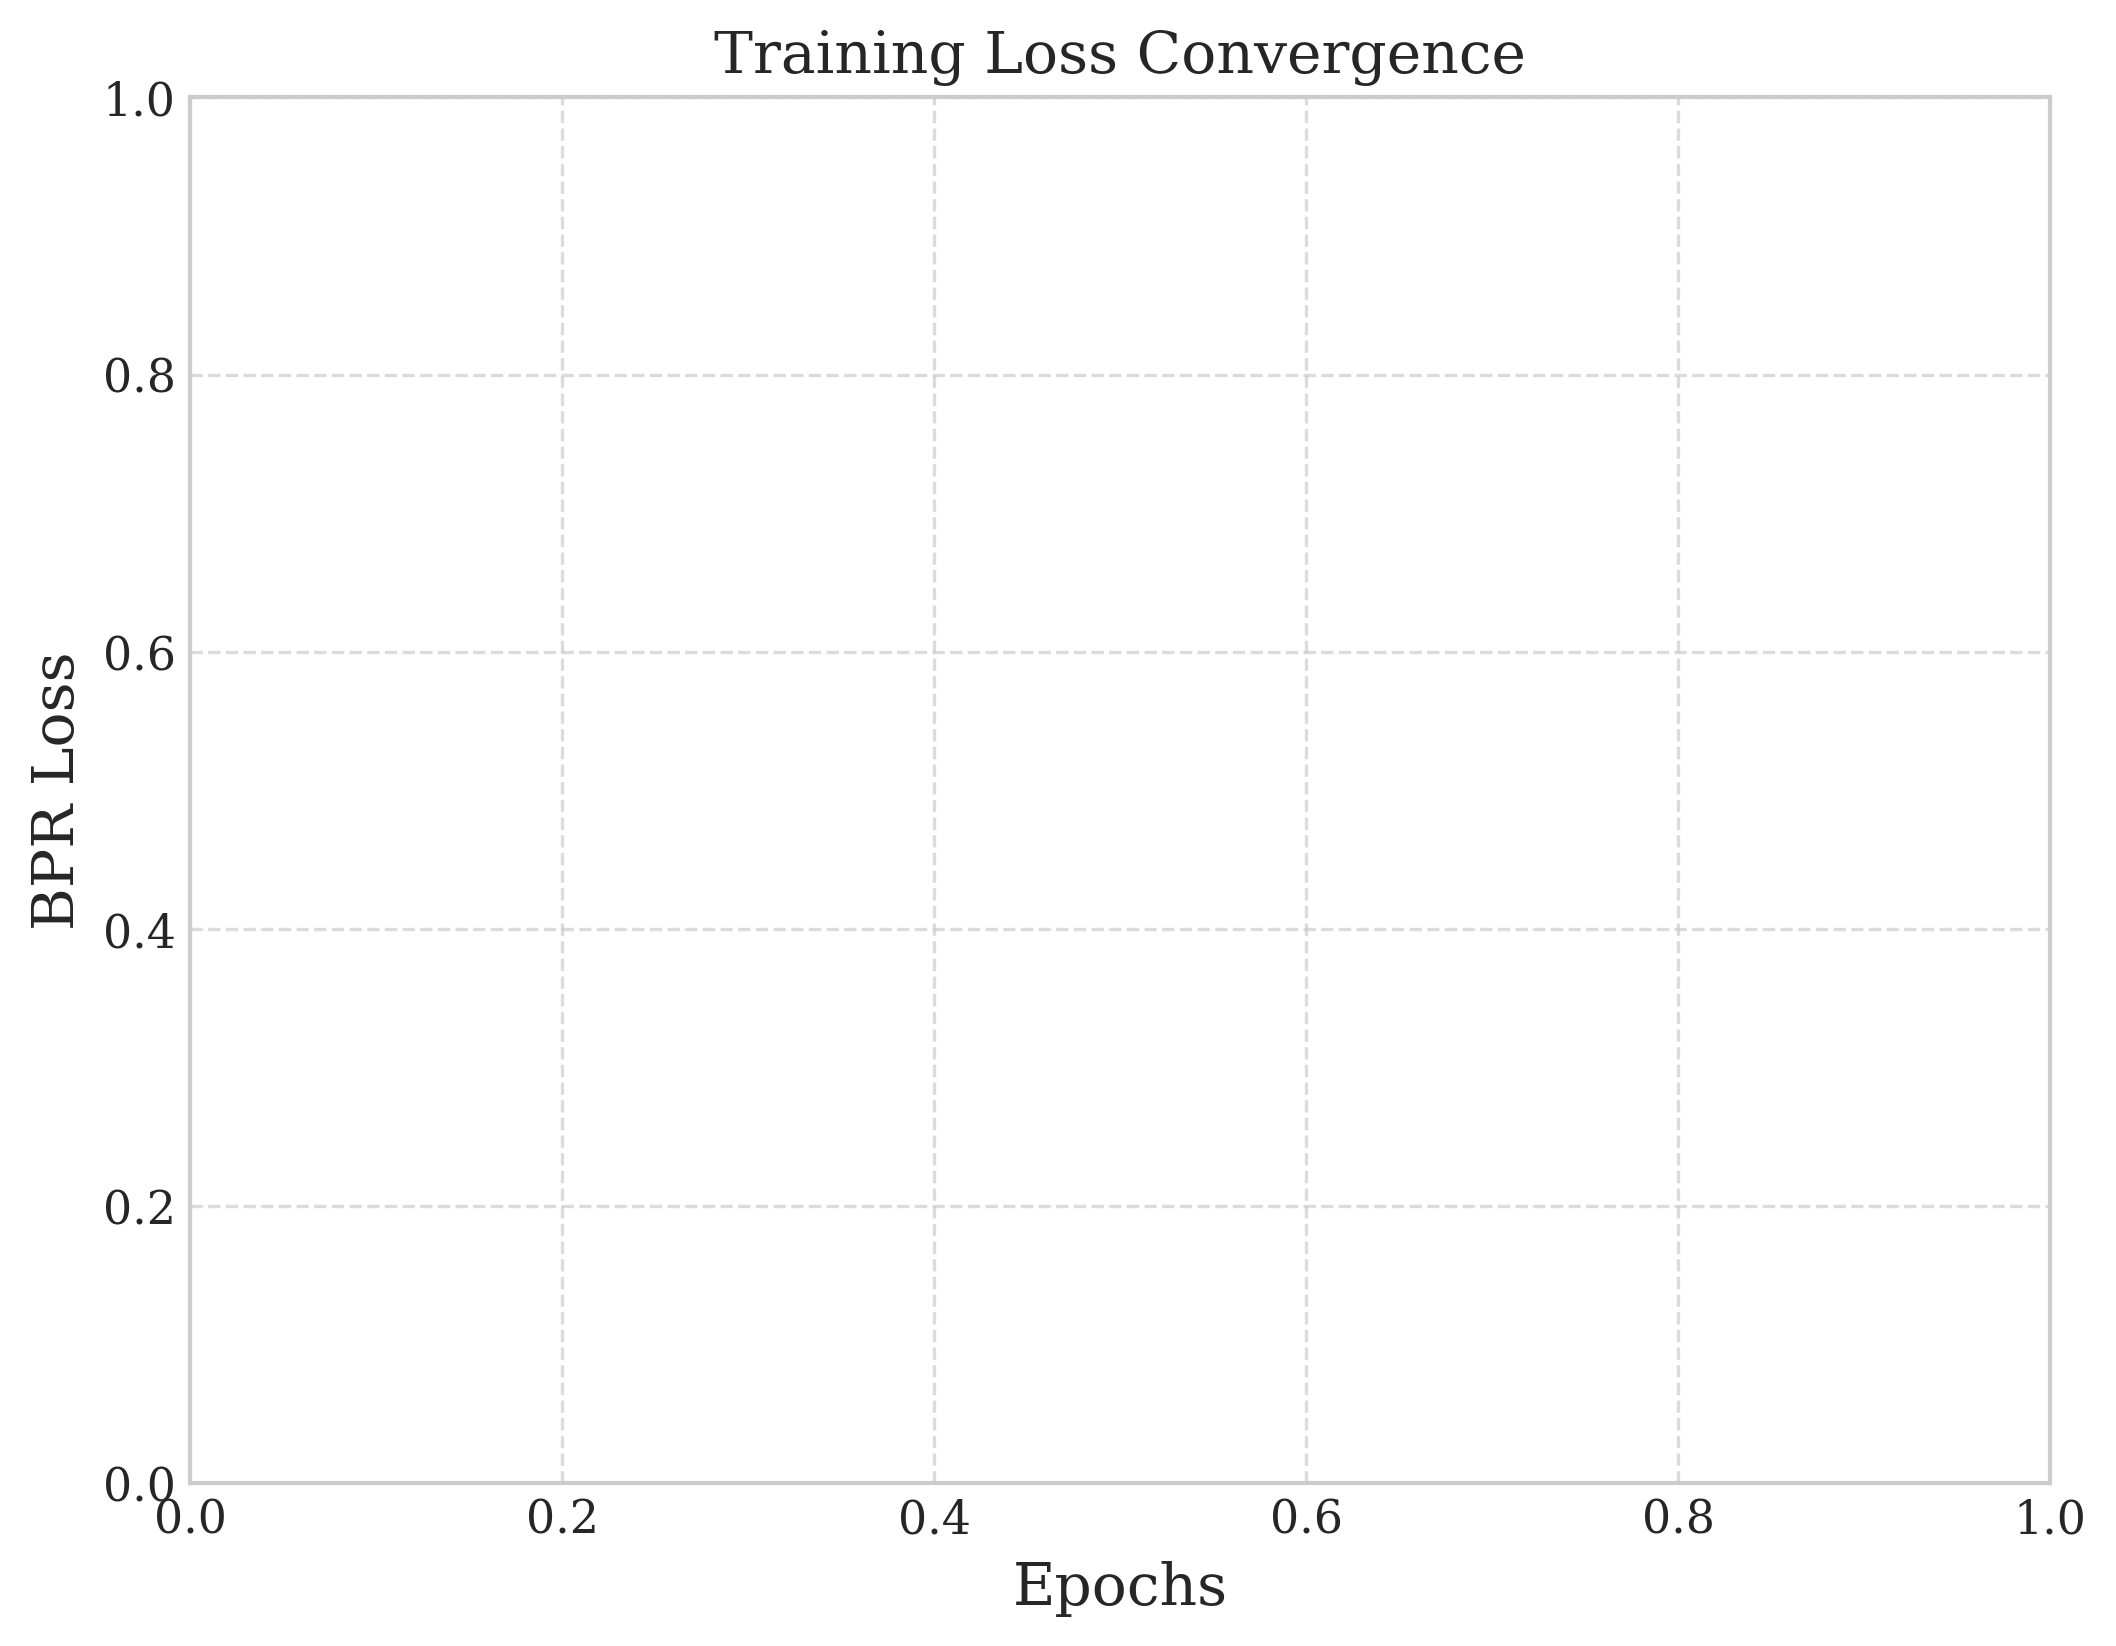

Generating t-SNE embeddings (this may take a minute)...


NameError: name 'model_sem' is not defined

In [ ]:
# Create a figures directory
# IEEE Publication-Grade Styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'legend.fontsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 300,
    'lines.linewidth': 2.5
})
fig_path = f"{base_path}/figures"
os.makedirs(fig_path, exist_ok=True)

# ---------------------------------------------------------
# Figure 3: Training Loss Curves
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
for model_name, history in all_loss_histories.items():
    plt.plot(history, label=model_name, linewidth=2)
plt.title("Training Loss Convergence")
plt.xlabel("Epochs")
plt.ylabel("BPR Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.savefig(f"{fig_path}/training_loss.png", dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------
# Figure 2: t-SNE Embeddings (LightGCN vs S-LightGCN)
# ---------------------------------------------------------
print("Generating t-SNE embeddings (this may take a minute)...")
model_base = LightGCN(n_users, n_items, 64, 3).to(device)
model_base.load_state_dict(torch.load(f"{base_path}/lightgcn_baseline.pt"))
model_base.eval()
model_sem.eval()

with torch.no_grad():
    _, base_items = model_base(adj_norm_torch)
    _, sem_items = model_sem(adj_norm_torch)

# Randomly sample 1000 items to keep plot readable
np.random.seed(42)
sample_idx = np.random.choice(n_items, 1000, replace=False)

base_items_sample = base_items[sample_idx].cpu().numpy()
sem_items_sample = sem_items[sample_idx].cpu().numpy()

tsne1 = TSNE(n_components=2, perplexity=30, random_state=42)
tsne2 = TSNE(n_components=2, perplexity=30, random_state=42)
base_tsne = tsne1.fit_transform(base_items_sample)
sem_tsne = tsne2.fit_transform(sem_items_sample)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))
ax1.scatter(base_tsne[:, 0], base_tsne[:, 1], alpha=0.6, c='royalblue', s=15)
ax1.set_title("LightGCN Item Embeddings")
ax2.scatter(sem_tsne[:, 0], sem_tsne[:, 1], alpha=0.6, c='seagreen', s=15)
ax2.set_title("S-LightGCN Item Embeddings")

plt.savefig(f"{fig_path}/tsne_embeddings.png", dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
print("\nEvaluating Alpha Sensitivity for Figure 3...")
alpha_values = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]
alpha_recalls = []

for a in alpha_values:
    print(f"Training static S-LightGCN with fixed \u03B1 = {a}...")
    temp_model = SLightGCN(n_users, n_items, 64, 3, text_matrix, alpha=a).to(device)
    train_model(temp_model, epochs=30)

    # Run a quick evaluation just for Recall@10
    temp_model.eval()
    hits = []
    with torch.no_grad():
        users_emb, items_emb = temp_model(adj_norm_torch)
        for user in test["userId"].unique():
            test_item = test_dict[user]
            scores = torch.matmul(items_emb, users_emb[user])
            seen = train[train["userId"]==user]["itemId"].values
            scores[seen] = -1e9
            _, topk = torch.topk(scores, 10)
            hits.append(int(test_item in topk.cpu().numpy()))
    alpha_recalls.append(np.mean(hits))

plt.figure(figsize=(8, 6))
plt.plot(alpha_values, alpha_recalls, marker='o', linestyle='-', color='indigo', linewidth=2)
plt.title("Impact of Semantic Fusion Weight (\u03B1) on Recall@10")
plt.xlabel("Semantic Weight (\u03B1)")
plt.ylabel("Recall@10")
plt.grid(True, linestyle="--", alpha=0.7)
plt.savefig(f"{fig_path}/alpha_sensitivity.png", dpi=300, bbox_inches='tight')
plt.show()


Evaluating Alpha Sensitivity for Figure 3...
Training static S-LightGCN with fixed α = 0.0...
Epoch 0 | Loss: 0.6299
Epoch 1 | Loss: 0.4086
Epoch 2 | Loss: 0.2819
Epoch 3 | Loss: 0.2239
Epoch 4 | Loss: 0.1910
Epoch 5 | Loss: 0.1672
Epoch 6 | Loss: 0.1469
Epoch 7 | Loss: 0.1301
Epoch 8 | Loss: 0.1175
Epoch 9 | Loss: 0.1057
Epoch 10 | Loss: 0.0978
Epoch 11 | Loss: 0.0888
Epoch 12 | Loss: 0.0805
Epoch 13 | Loss: 0.0754
Epoch 14 | Loss: 0.0701
Epoch 15 | Loss: 0.0649
Epoch 16 | Loss: 0.0613
Epoch 17 | Loss: 0.0566
Epoch 18 | Loss: 0.0534
Epoch 19 | Loss: 0.0513
Epoch 20 | Loss: 0.0480
Epoch 21 | Loss: 0.0456
Epoch 22 | Loss: 0.0429
Epoch 23 | Loss: 0.0403
Epoch 24 | Loss: 0.0391
Epoch 25 | Loss: 0.0364


In [ ]:
print(alpha_recalls)
print(alpha_values)

[np.float64(0.07632457238214435), np.float64(0.06962870254484772), np.float64(0.06572799332498958), np.float64(0.06693783896537338), np.float64(0.06925323320817689), np.float64(0.07530246141009596)]
[0.0, 0.05, 0.1, 0.2, 0.3, 0.5]


Successfully loaded results.json!

Generating Performance Comparison Plots...


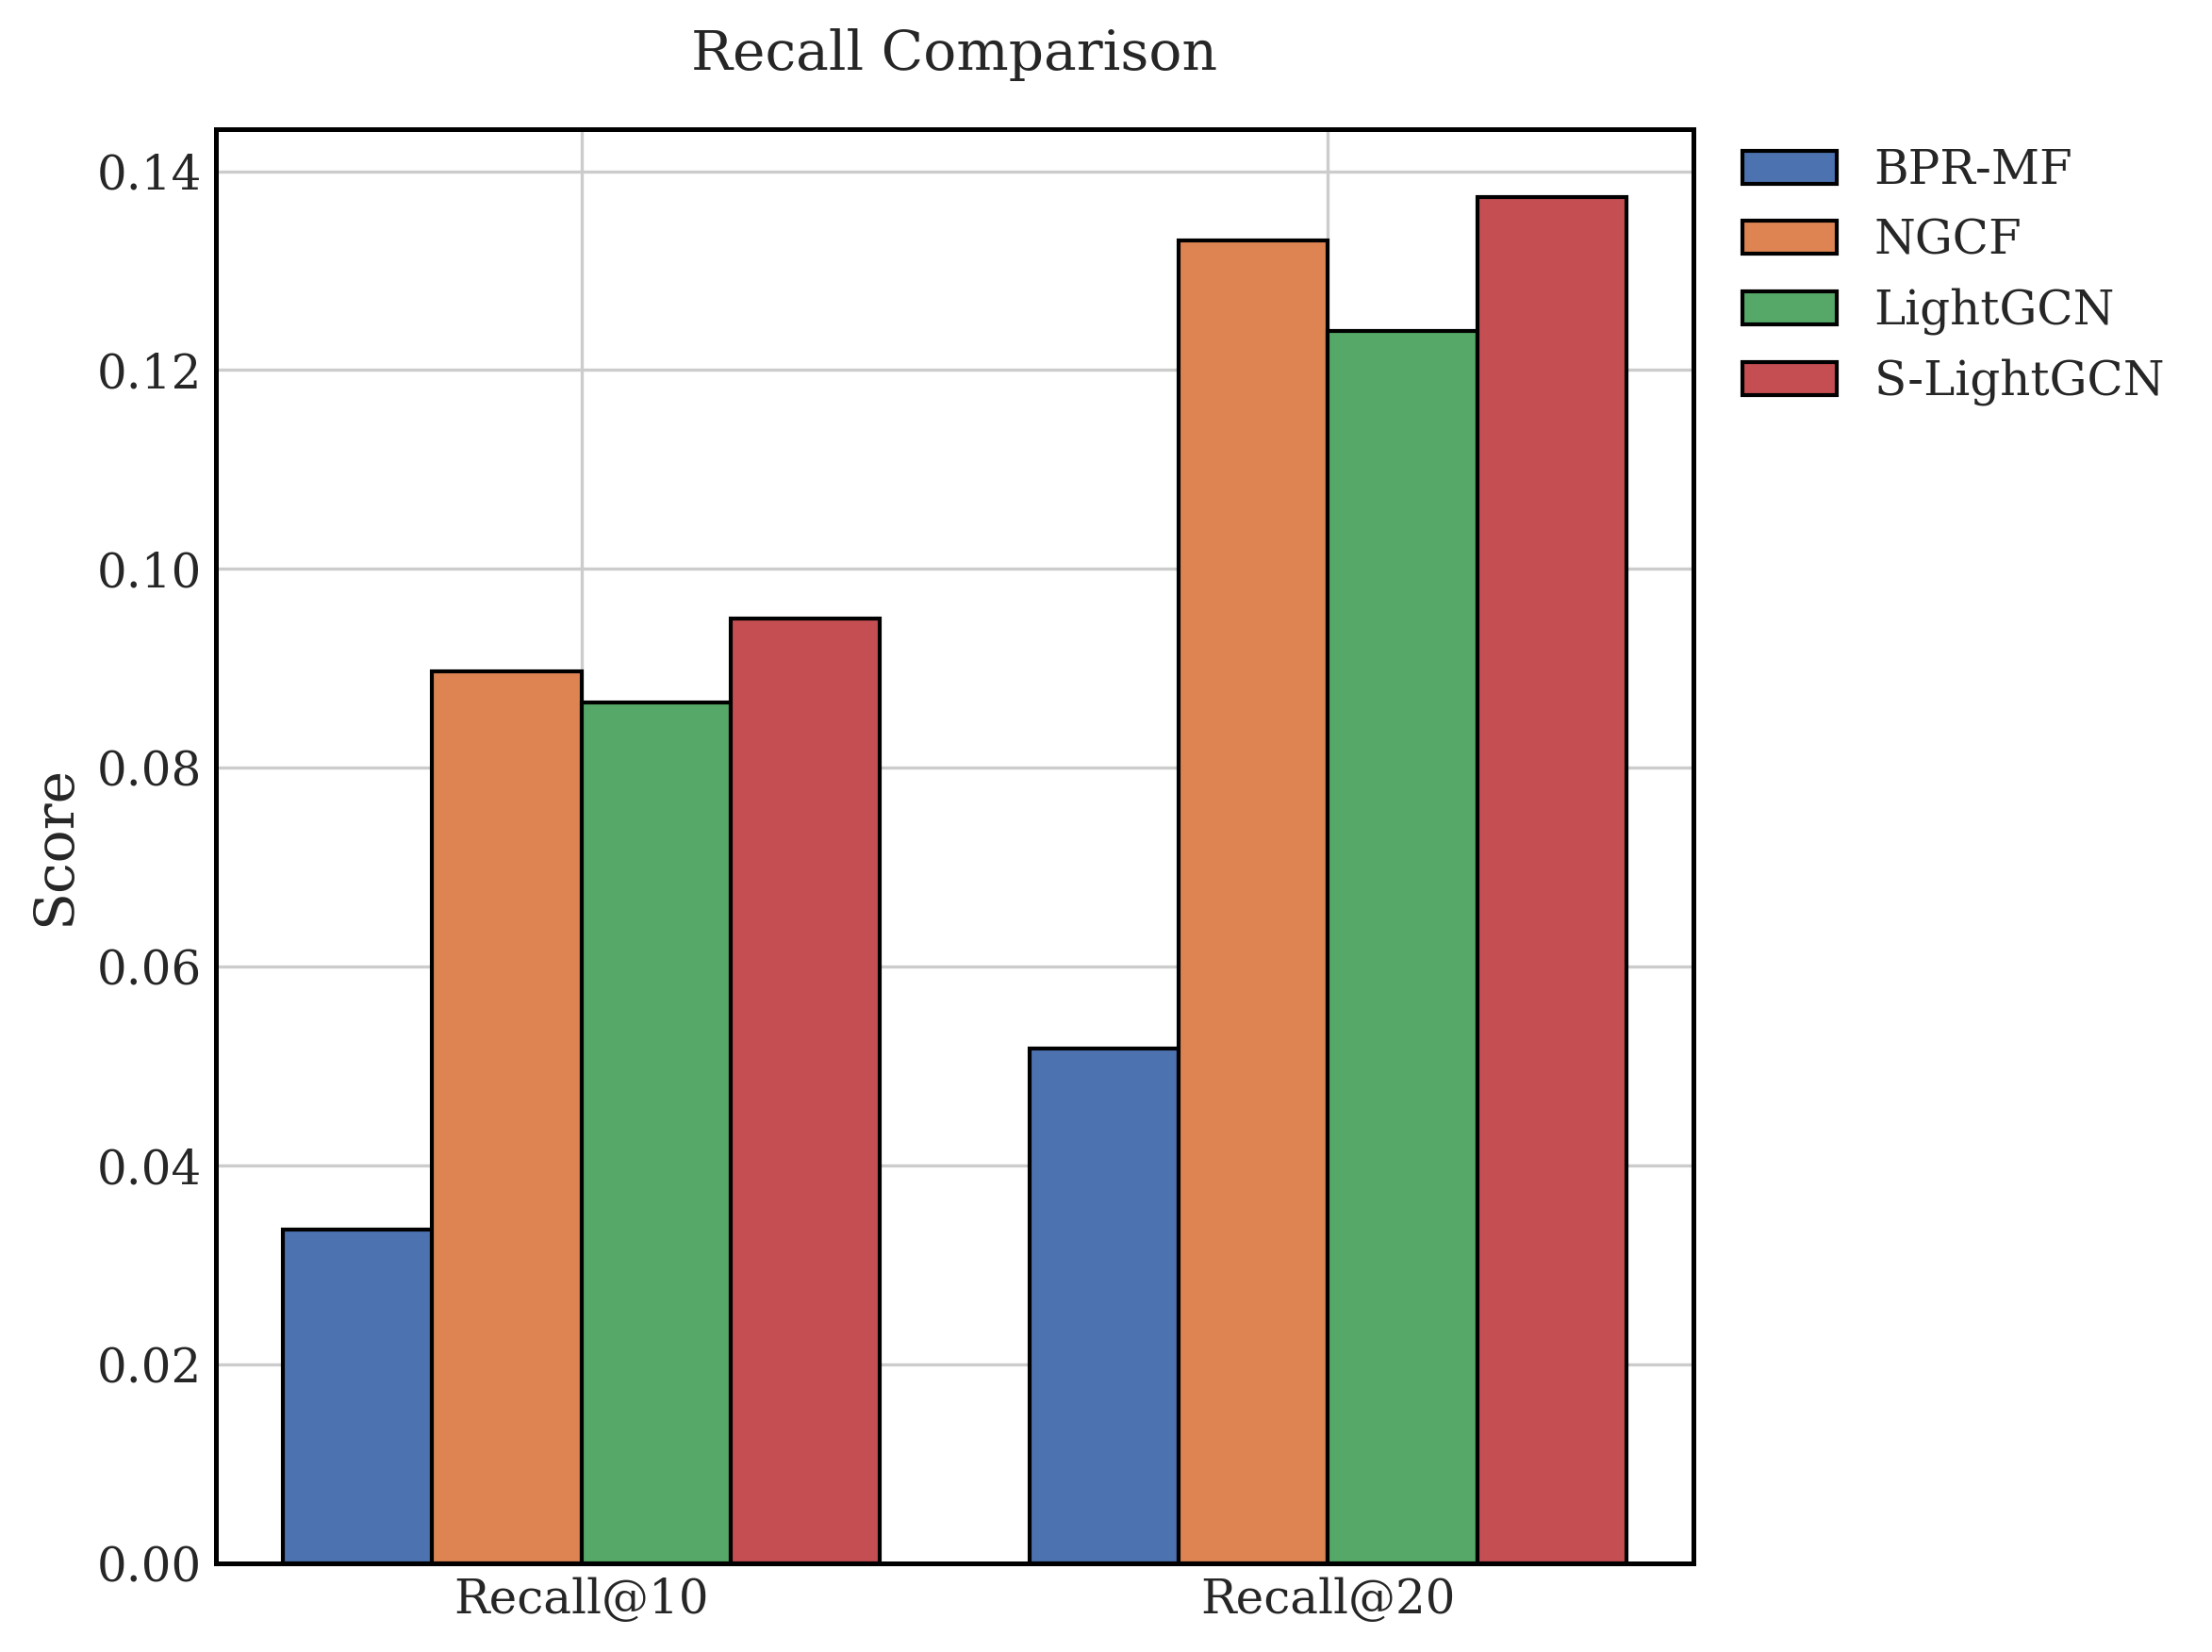

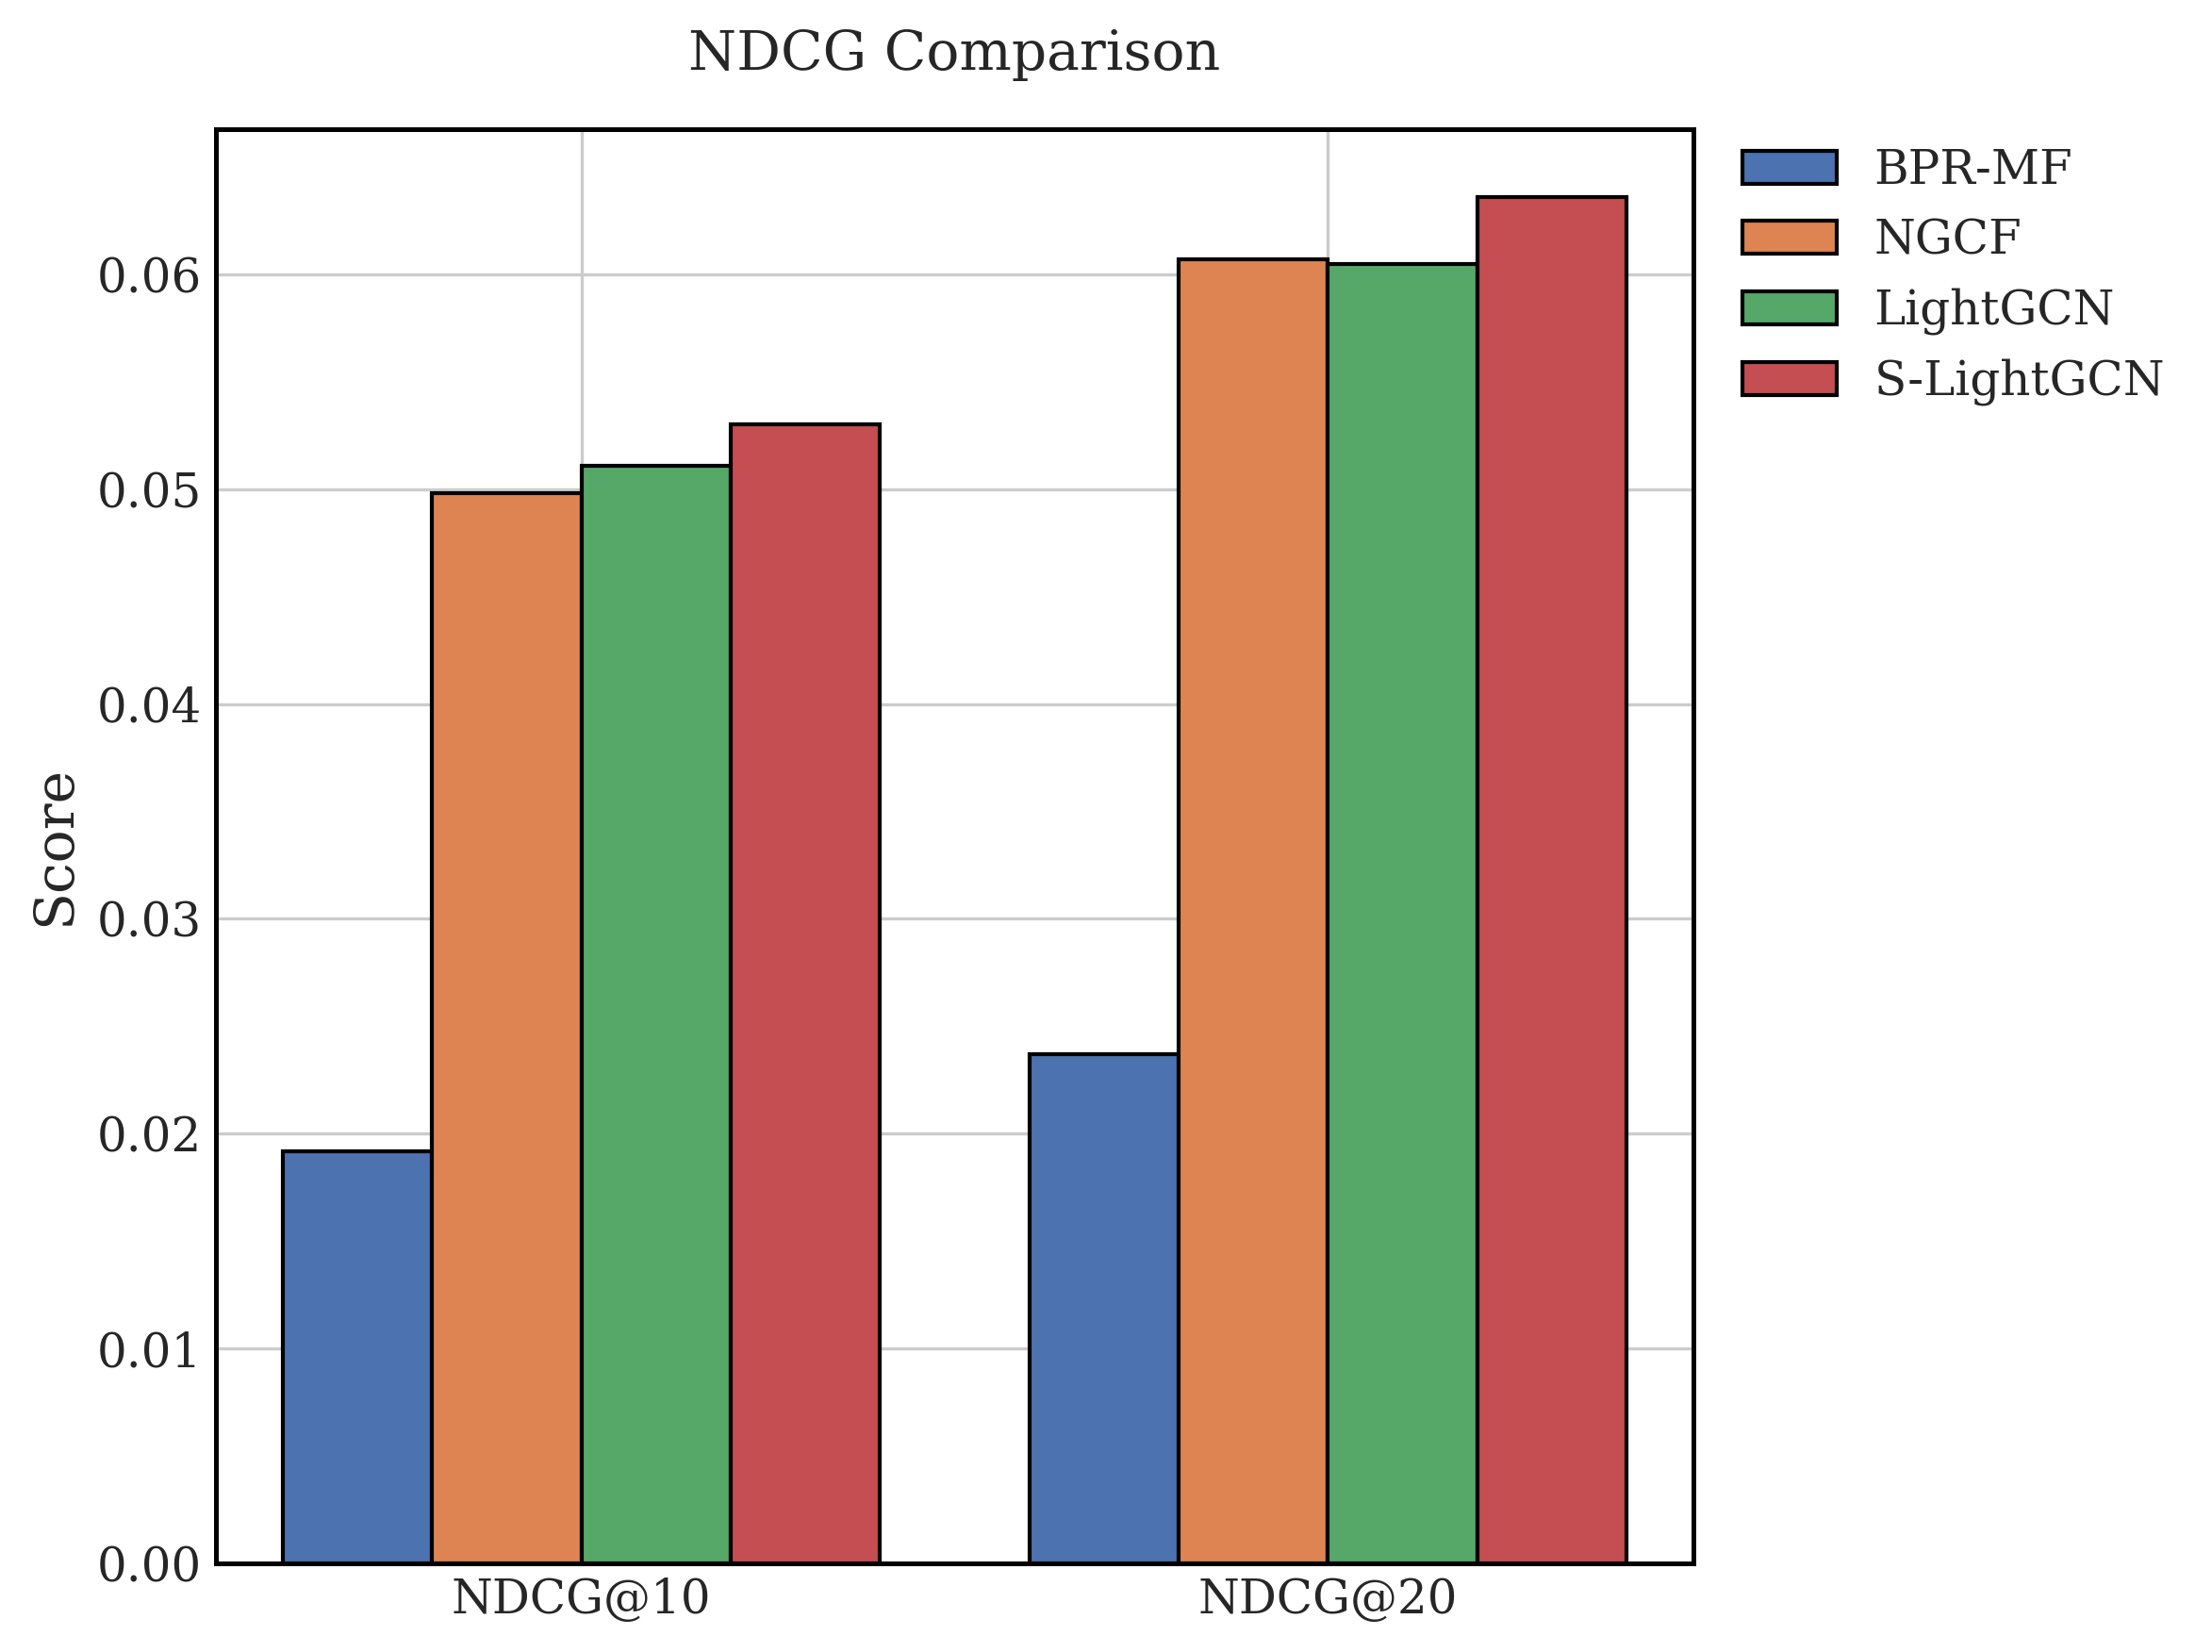

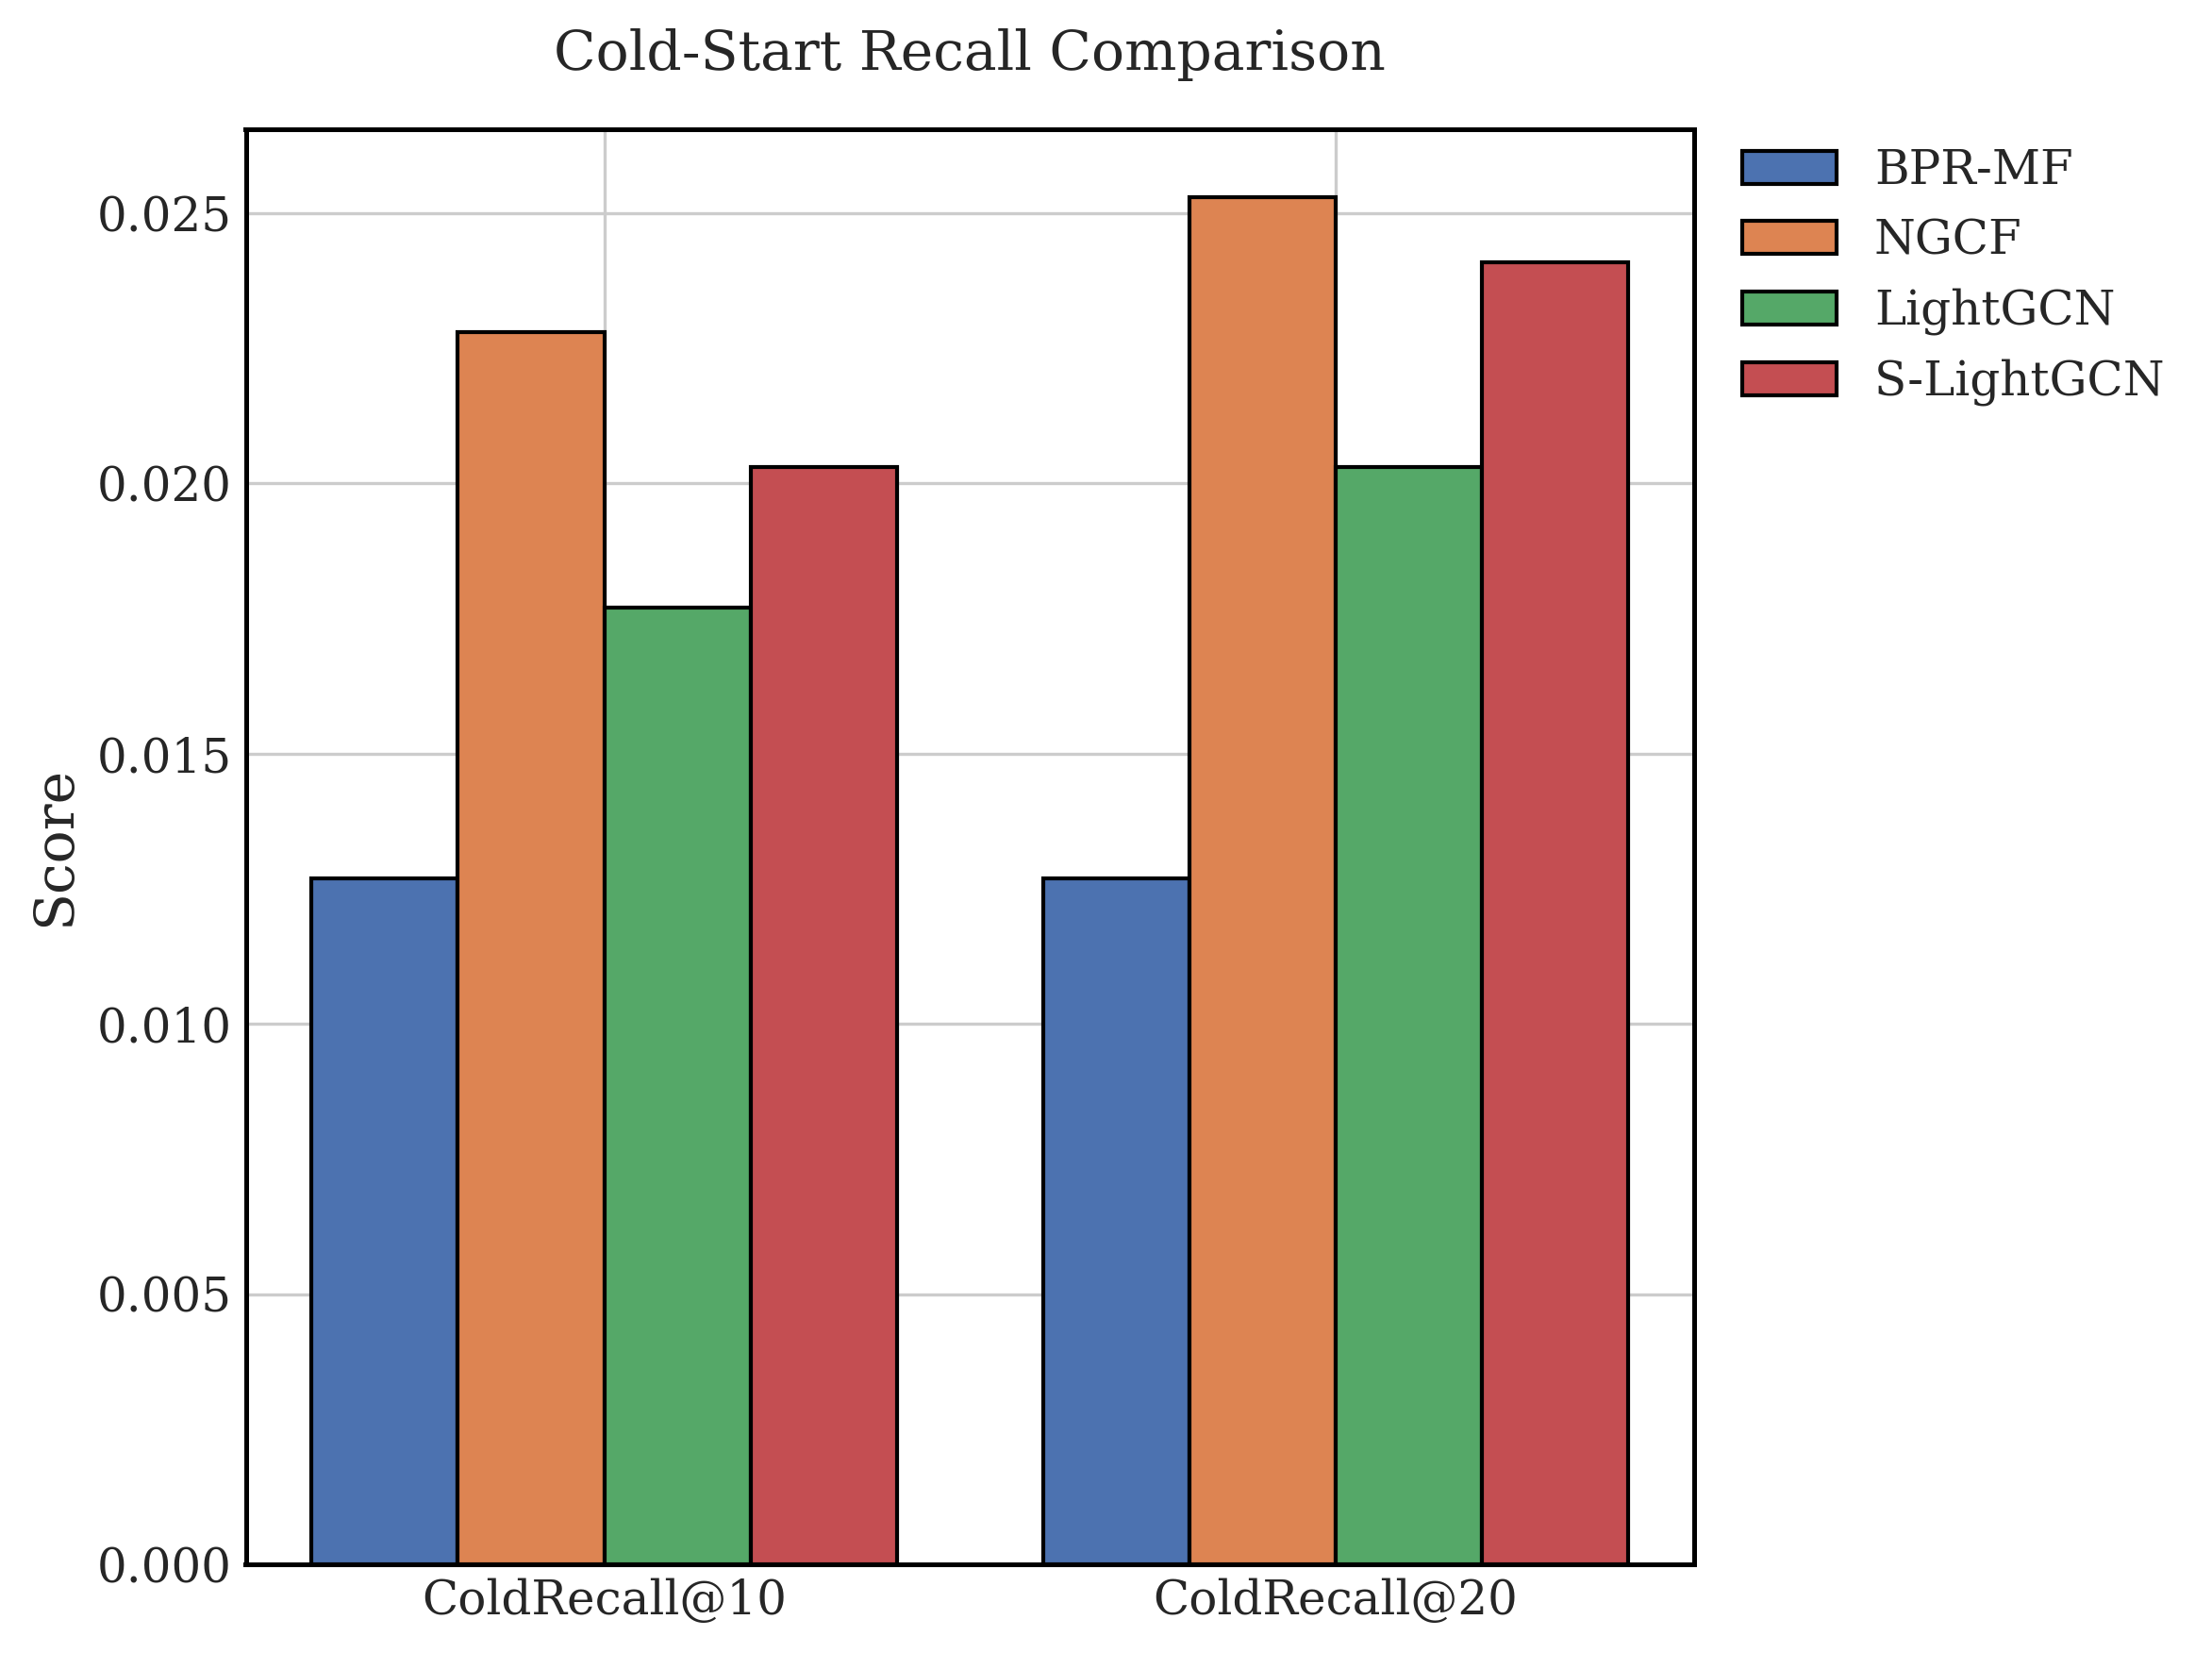


All comparison plots saved to /content/drive/MyDrive/slightgcn/figures successfully!


In [ ]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt

# --- SETUP PATHS ---
base_path = "/content/drive/MyDrive/slightgcn"
fig_path = f"{base_path}/figures"
os.makedirs(fig_path, exist_ok=True)

# --- IEEE PUBLICATION-GRADE STYLING ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.dpi': 300,
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.2
})

# --- LOAD RESULTS.JSON ---
results_file = f"{base_path}/results.json"
try:
    with open(results_file, "r") as f:
        results = json.load(f)
    print("Successfully loaded results.json!")
except FileNotFoundError:
    print(f"Error: Could not find {results_file}. Please ensure you have trained the models and saved the results.")
    results = {}

# --- PLOTTING FUNCTION ---
models = ["BPR-MF", "NGCF", "LightGCN", "S-LightGCN"]

# Colors optimized for academic papers (colorblind friendly & distinct)
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
def plot_metric_group(metric_name, title, filename):
    k_vals = ["@10", "@20"]
    x = np.arange(len(k_vals))
    width = 0.2  # Width of the bars

    fig, ax = plt.subplots(figsize=(8, 6))

    # Create bars for each model
    for i, model in enumerate(models):
        # Fetch the metric, default to 0 if something is missing
        vals = [results.get(f"{model}_{metric_name}{k}", 0) for k in k_vals]

        # Offset bars so they sit side-by-side
        offset = (i - 1.5) * width
        ax.bar(x + offset, vals, width, label=model, color=colors[i], edgecolor='black', linewidth=1)

    # Styling and labeling
    ax.set_ylabel('Score')
    ax.set_title(title, pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{metric_name}@10", f"{metric_name}@20"])

    # Place legend outside the plot if it overlaps with bars, or keep it inside if there's room
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)

    plt.tight_layout()
    plt.savefig(f"{fig_path}/{filename}.png", dpi=300, bbox_inches='tight')
    plt.show()

# --- GENERATE PLOTS ---
if results:
    print("\nGenerating Performance Comparison Plots...")

    # 1. Overall Recall Plot
    plot_metric_group("Recall", "Recall Comparison", "model_comparison_recall")

    # 2. Overall NDCG Plot
    plot_metric_group("NDCG", "NDCG Comparison", "model_comparison_ndcg")

    # 3. Cold-Start Recall Plot
    plot_metric_group("ColdRecall", "Cold-Start Recall Comparison", "model_comparison_cold_recall")

    print(f"\nAll comparison plots saved to {fig_path} successfully!")